In [ ]:
from google.colab import files
uploaded = files.upload()


Saving employe.csv to employe.csv


In [ ]:
import pandas as pd
df = pd.read_csv('employe.csv')
df.head()


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


Q1: What is the current workforce size, and how many employees have already left the organization?

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects', 'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left', 'promotionInLast5years', 'dept', 'salary']


In [ ]:
total_employees = df.shape[0]
left_employees = df[df['left'] == 1].shape[0]
stayed_employees = df[df['left'] == 0].shape[0]
print("Total Employees:", total_employees)
print("Employees Who Left:", left_employees)
print("Employees Still Here:", stayed_employees)



Total Employees: 14999
Employees Who Left: 3571
Employees Still Here: 11428


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")


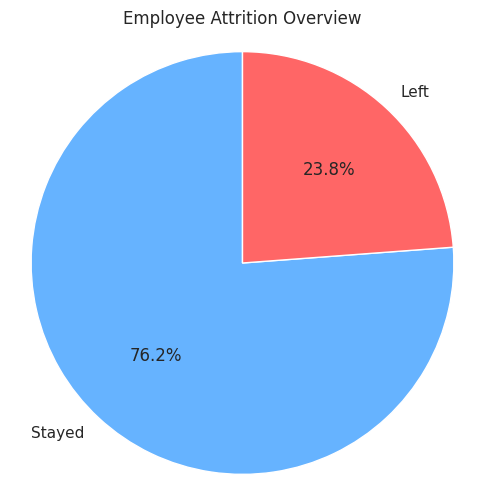

In [ ]:
labels = ['Stayed', 'Left']
sizes = [stayed_employees, left_employees]
colors = ['#66b3ff', '#ff6666']
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Employee Attrition Overview')
plt.axis('equal')
plt.show()



Q2: Which departments are experiencing the highest attrition?


In [ ]:
left_df = df[df['left'] == 1]
dept_attrition = left_df['dept'].value_counts()
print(dept_attrition)


dept
sales          1014
technical       697
support         555
IT              273
hr              215
accounting      204
marketing       203
product_mng     198
RandD           121
management       91
Name: count, dtype: int64


/tmp/ipython-input-15-1278869774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.values, y=dept_attrition.index, palette='Set2')


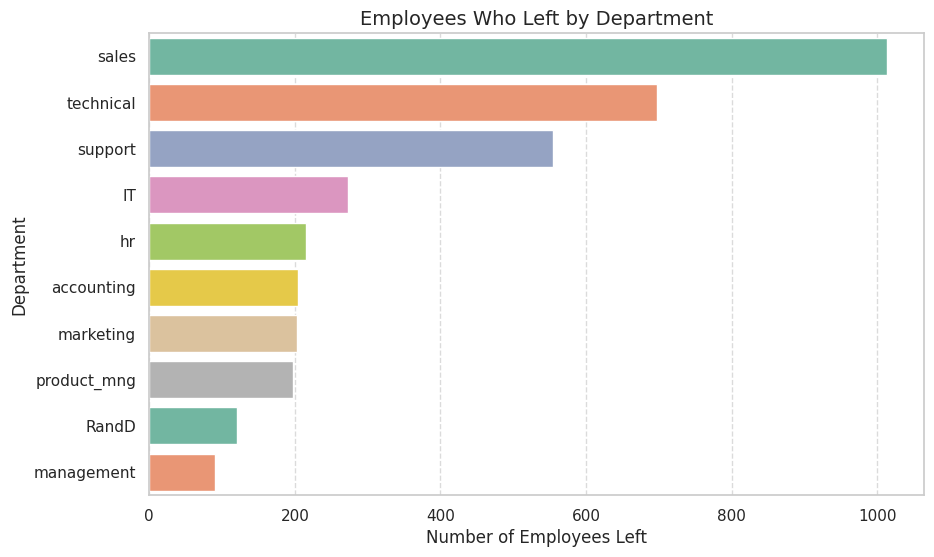

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=dept_attrition.values, y=dept_attrition.index, palette='Set2')
plt.title('Employees Who Left by Department', fontsize=14)
plt.xlabel('Number of Employees Left')
plt.ylabel('Department')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


percentage of employees who left from each department:

/tmp/ipython-input-22-336355511.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_rate.values, y=attrition_rate.index, palette='coolwarm')


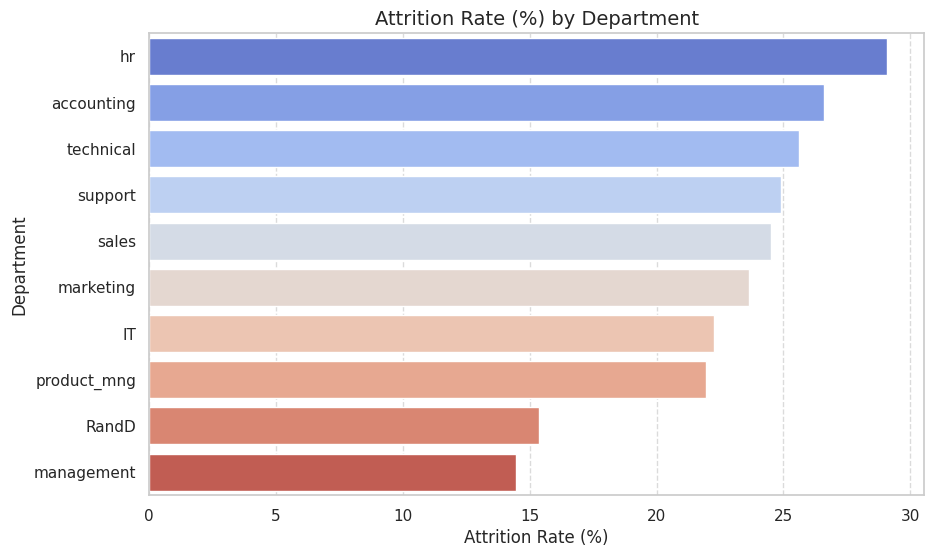

dept
hr             29.09
accounting     26.60
technical      25.62
support        24.90
sales          24.49
marketing      23.66
IT             22.25
product_mng    21.95
RandD          15.37
management     14.44
Name: count, dtype: float64


In [ ]:
total_per_dept = df['dept'].value_counts()
left_per_dept = df[df['left'] == 1]['dept'].value_counts()
attrition_rate = (left_per_dept / total_per_dept) * 100
attrition_rate = attrition_rate.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=attrition_rate.values, y=attrition_rate.index, palette='coolwarm')
plt.title("Attrition Rate (%) by Department", fontsize=14)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
print(attrition_rate.round(2))


Q3: Are employees working on fewer than 3 projects more likely to leave the company?

In [ ]:
few_projects_df = df[df['numberOfProjects'] < 3]
few_projects_attrition = few_projects_df['left'].value_counts()
print("Attrition breakdown for employees with < 3 projects:")
print(few_projects_attrition)
left_count = few_projects_attrition.get(1, 0)
total_few_projects = few_projects_df.shape[0]
left_percent = (left_count / total_few_projects) * 100
print(f"\nPercentage of employees with <3 projects who left: {left_percent:.2f}%")


Attrition breakdown for employees with < 3 projects:
left
1    1567
0     821
Name: count, dtype: int64

Percentage of employees with <3 projects who left: 65.62%


/tmp/ipython-input-24-3067874813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=few_projects_df, x='left', palette='coolwarm')


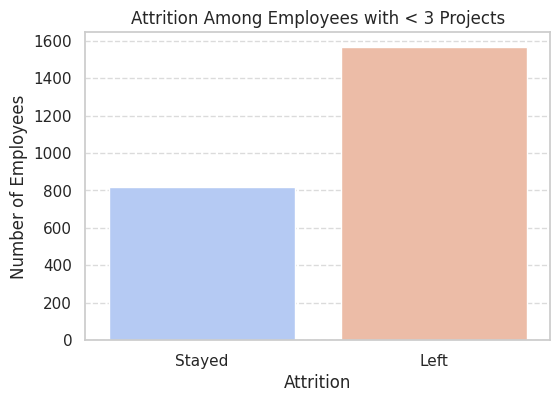

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=few_projects_df, x='left', palette='coolwarm')
plt.title('Attrition Among Employees with < 3 Projects')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Q4: How does the number of projects correlate with time spent at the company, particularly for those who have left?

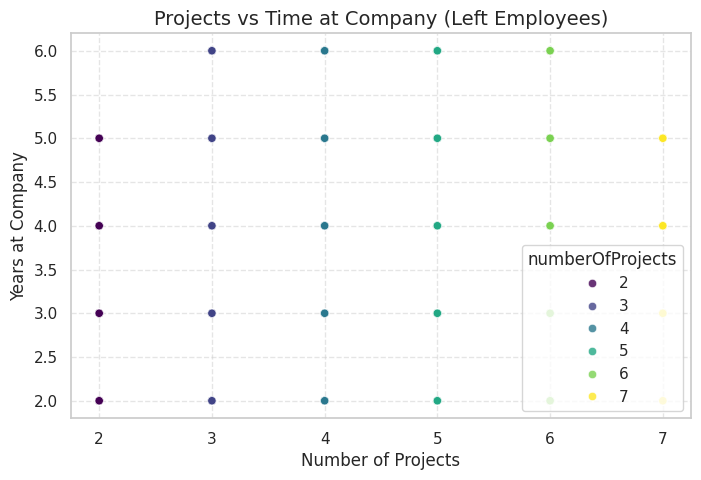

In [ ]:
left_employees_df = df[df['left'] == 1]
plt.figure(figsize=(8,5))
sns.scatterplot(data=left_employees_df,
                x='numberOfProjects',
                y='timeSpent.company',
                hue='numberOfProjects',
                palette='viridis',
                alpha=0.8)

plt.title('Projects vs Time at Company (Left Employees)', fontsize=14)
plt.xlabel('Number of Projects')
plt.ylabel('Years at Company')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


/tmp/ipython-input-26-1924131991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=left_employees_df,


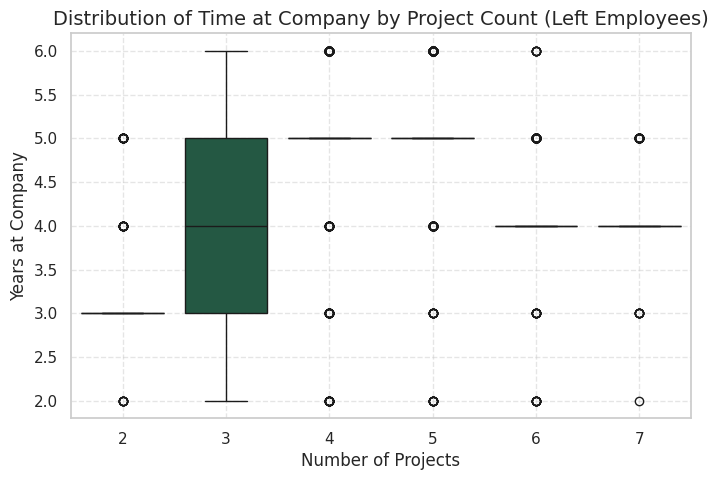

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=left_employees_df,
            x='numberOfProjects',
            y='timeSpent.company',
            palette='cubehelix')

plt.title('Distribution of Time at Company by Project Count (Left Employees)', fontsize=14)
plt.xlabel('Number of Projects')
plt.ylabel('Years at Company')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Q5: Could compensation levels be influencing an employee’s decision to leave?

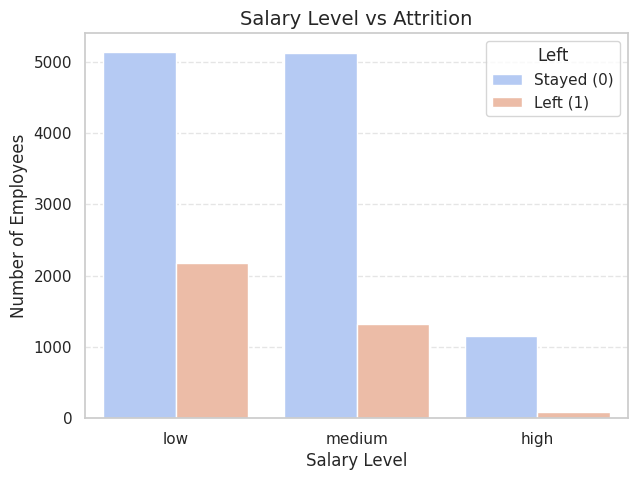

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='salary', hue='left', palette='coolwarm')
plt.title("Salary Level vs Attrition", fontsize=14)
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


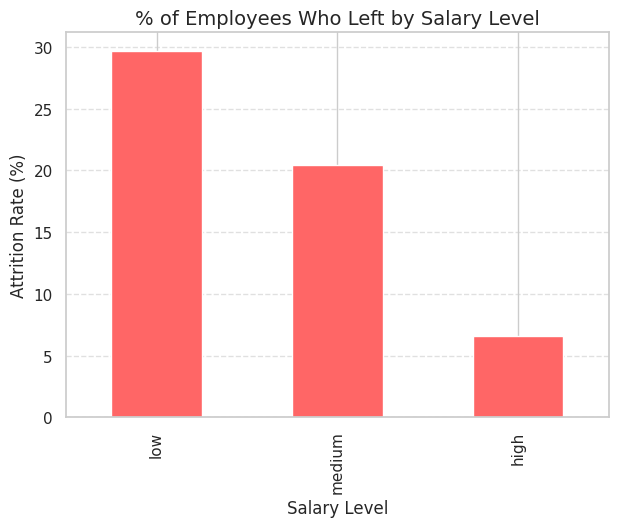

        Stayed (%)  Left (%)
salary                      
high         93.37      6.63
low          70.31     29.69
medium       79.57     20.43


In [ ]:
salary_left = df.groupby('salary')['left'].value_counts(normalize=True).unstack() * 100
salary_left.columns = ['Stayed (%)', 'Left (%)']
salary_left['Left (%)'].sort_values(ascending=False).plot(kind='bar', figsize=(7,5), color='#ff6666')
plt.title("% of Employees Who Left by Salary Level", fontsize=14)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Salary Level")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
print(salary_left.round(2))
